EDA – Données synthétiques des urgences (Hôpital Pitié-Salpêtrière)
Analyse exploratoire de données fictives (2022–2025) visant à vérifier leur cohérence avant la modélisation prédictive.

Objectif

- Vérifier la qualité et la cohérence des données
- Identifier les tendances principales (saisonnalité, épidémies, pression ressources)
- Valider l’utilisation du dataset pour le ML

Datasets utilisés

- Visites aux urgences : 1 ligne = 1 patient (temps d’attente, triage, orientation)

- Contexte journalier : lits, personnel, épidémies, événements

Les deux datasets sont analysés séparément puis fusionnés par date.

Conclusion

Les analyses (statistiques, graphiques et corrélations) montrent des relations cohérentes entre admissions, saisonnalité, épidémies et ressources.

In [6]:
# Setup & Chargement
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 4)

df_visits = pd.read_csv("../data/raw/ed_visits_pitie_salpetriere_synthetic.csv", parse_dates=['arrival_datetime'])
df_context = pd.read_csv("../data/raw/daily_context.csv", parse_dates=['date'])

df_visits['date'] = df_visits['arrival_datetime'].dt.date.astype('datetime64[ns]')

print(f"Visites: {len(df_visits):,} lignes | Contexte: {len(df_context):,} jours")
print(f"Période: {df_visits['date'].min().date()} → {df_visits['date'].max().date()}")

Visites: 100,000 lignes | Contexte: 1,461 jours
Période: 2022-01-01 → 2025-12-31


In [7]:
# Aperçu rapide
display(df_visits.head(3))
display(df_context.head(3))
print(f"\nValeurs manquantes visites: {df_visits.isnull().sum().sum()}")
print(f"Valeurs manquantes contexte: {df_context.isnull().sum().sum()}")

,visit_id,arrival_datetime,date,year,month,day_of_week,is_weekend,is_holiday_fr,age,age_group,...,staff_nurses_available,staff_absence_rate,ppe_stock_index,critical_stockout,flu_level,bronchiolitis_level,covid_level,heatwave,strike,mass_casualty_event
0,72,2022-01-01 00:30:20,2022-01-01,2022,1,5,1,1,34,18-39,...,59,0.111,85,0,0.0,0.0,0.257516,0,0,0
1,22,2022-01-01 01:01:27,2022-01-01,2022,1,5,1,1,73,65+,...,59,0.111,85,0,0.0,0.0,0.257516,0,0,0
2,12,2022-01-01 01:04:30,2022-01-01,2022,1,5,1,1,23,18-39,...,59,0.111,85,0,0.0,0.0,0.257516,0,0,0


,date,year,month,day_of_week,is_weekend,is_holiday_fr,visits_count,admissions_count,lwbs_count,avg_wait_time,...,staff_nurses_available,staff_absence_rate,ppe_stock_index,critical_stockout,flu_level,bronchiolitis_level,covid_level,heatwave,strike,mass_casualty_event
0,2022-01-01,2022,1,5,1,1,89,21,5,85.6,...,59,0.111,85,0,0.0,0.0,0.258,0,0,0
1,2022-01-02,2022,1,6,1,0,80,26,2,75.2,...,87,0.093,84,0,0.0,0.0,0.281,0,0,0
2,2022-01-03,2022,1,0,0,0,93,22,4,74.8,...,109,0.095,87,0,0.0,0.0,0.305,0,0,0



Valeurs manquantes visites: 66679
Valeurs manquantes contexte: 0


In [ ]:
## Sanity Checks

=== Dataset Contexte Journalier ===


,date,year,month,day_of_week,is_weekend,is_holiday_fr,visits_count,admissions_count,lwbs_count,avg_wait_time,...,staff_nurses_available,staff_absence_rate,ppe_stock_index,critical_stockout,flu_level,bronchiolitis_level,covid_level,heatwave,strike,mass_casualty_event
0,2022-01-01,2022,1,5,1,1,89,21,5,85.6,...,59,0.111,85,0,0.0,0.0,0.258,0,0,0
1,2022-01-02,2022,1,6,1,0,80,26,2,75.2,...,87,0.093,84,0,0.0,0.0,0.281,0,0,0
2,2022-01-03,2022,1,0,0,0,93,22,4,74.8,...,109,0.095,87,0,0.0,0.0,0.305,0,0,0
3,2022-01-04,2022,1,1,0,0,88,23,1,49.9,...,106,0.115,87,0,0.0,0.0,0.330,0,0,0
4,2022-01-05,2022,1,2,0,0,70,19,1,54.4,...,107,0.112,86,0,0.0,0.0,0.356,0,0,0



Types des colonnes:
date                           str
year                         int64
month                        int64
day_of_week                  int64
is_weekend                   int64
is_holiday_fr                int64
visits_count                 int64
admissions_count             int64
lwbs_count                   int64
avg_wait_time              float64
avg_los_ed                 float64
beds_total                   int64
beds_occupied                int64
icu_beds_total               int64
icu_beds_occupied            int64
staff_doctors_available      int64
staff_nurses_available       int64
staff_absence_rate         float64
ppe_stock_index              int64
critical_stockout            int64
flu_level                  float64
bronchiolitis_level        float64
covid_level                float64
heatwave                     int64
strike                       int64
mass_casualty_event          int64
dtype: object


In [8]:
# Vérifications de cohérence
checks = [
    ("wait_time >= 0", (df_visits['wait_time_minutes'] >= 0).all()),
    ("los_ed >= 0", (df_visits['los_ed_minutes'] >= 0).all()),
    ("triage in [1-5]", df_visits['triage_level'].between(1, 5).all()),
    ("age in [0-120]", df_visits['age'].between(0, 120).all()),
    ("visit_id unique", df_visits['visit_id'].nunique() == len(df_visits)),
]
for name, ok in checks:
    print(f"{'✓' if ok else '✗'} {name}")

✓ wait_time >= 0
✓ los_ed >= 0
✓ triage in [1-5]
✓ age in [0-120]
✓ visit_id unique


In [ ]:
## Analyse Temporelle

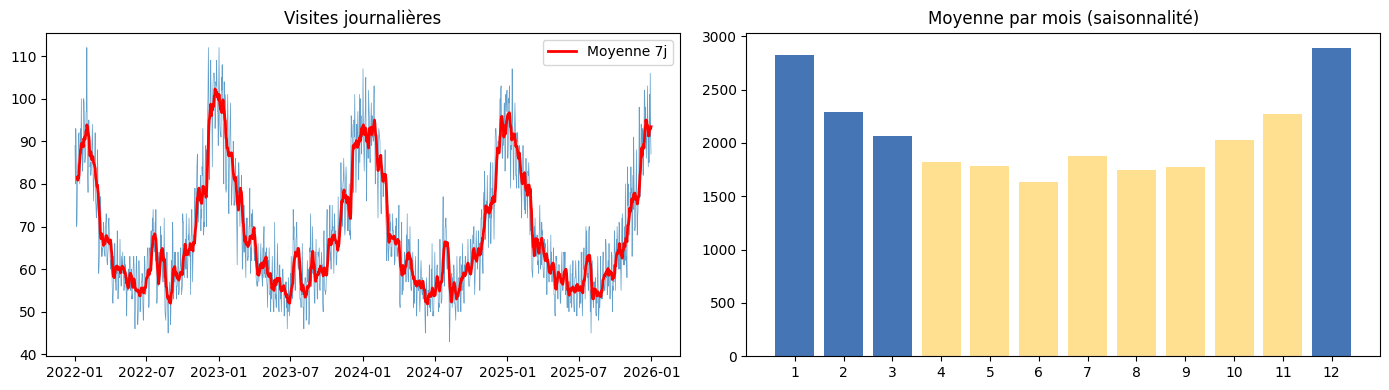

In [9]:
# Volume journalier + saisonnalité
daily = df_visits.groupby('date').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(daily.index, daily.values, lw=0.5, alpha=0.7)
axes[0].plot(daily.rolling(7).mean(), color='red', lw=2, label='Moyenne 7j')
axes[0].set_title('Visites journalières'); axes[0].legend()

monthly = df_visits.groupby(df_visits['date'].dt.month).size() / df_visits['date'].dt.year.nunique()
axes[1].bar(range(1,13), monthly.values, color=['#4575b4' if m in [12,1,2,3] else '#fee090' for m in range(1,13)])
axes[1].set_xticks(range(1,13)); axes[1].set_title('Moyenne par mois (saisonnalité)')
plt.tight_layout(); plt.show()

In [ ]:
## Impact des Événements

In [10]:
# Fonction helper pour comparer événement vs normal
def compare_event(event_col, event_name):
    event_dates = df_context[df_context[event_col] == 1]['date']
    v_event = df_visits[df_visits['date'].isin(event_dates)]
    v_normal = df_visits[~df_visits['date'].isin(event_dates)]
    
    return pd.DataFrame({
        'Normal': [len(v_normal)/max(len(df_context)-len(event_dates),1), 
                   v_normal['wait_time_minutes'].mean(),
                   v_normal['left_without_being_seen'].mean()*100],
        event_name: [len(v_event)/max(len(event_dates),1),
                     v_event['wait_time_minutes'].mean(),
                     v_event['left_without_being_seen'].mean()*100]
    }, index=['Visites/jour', 'Wait time (min)', 'LWBS (%)'])

# Comparaisons événements
print("=== CANICULE ===")
display(compare_event('heatwave', 'Canicule').round(1))

print("\n=== GRÈVE ===")
display(compare_event('strike', 'Grève').round(1))

print("\n=== ÉVÉNEMENT MAJEUR (MCE) ===")
display(compare_event('mass_casualty_event', 'MCE').round(1))

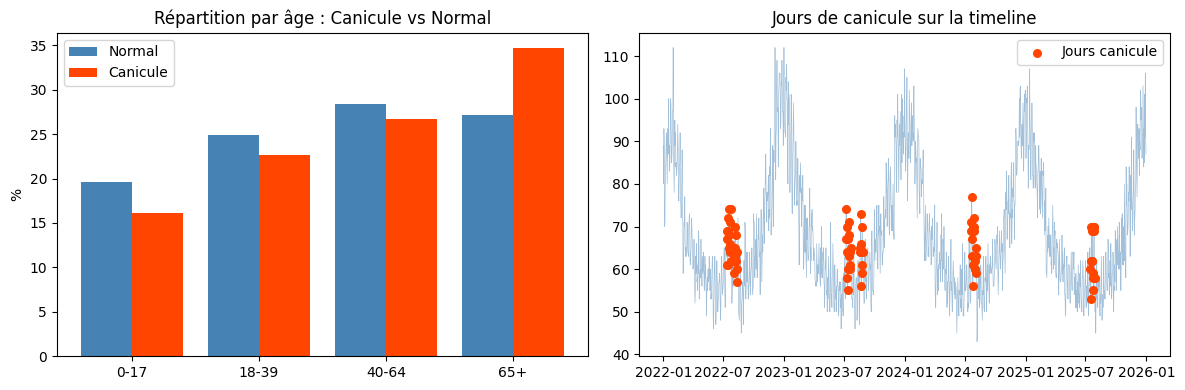

Part des 65+ : Normal=27.2% | Canicule=34.7%


In [18]:
# Graphique canicule : impact sur personnes âgées
hw_dates = df_context[df_context['heatwave'] == 1]['date']
v_hw = df_visits[df_visits['date'].isin(hw_dates)]
v_no_hw = df_visits[~df_visits['date'].isin(hw_dates)]

# Distribution par âge
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
bins = [0, 18, 40, 65, 100]
labels = ['0-17', '18-39', '40-64', '65+']
hw_age = pd.cut(v_hw['age'], bins=bins, labels=labels).value_counts(normalize=True).sort_index() * 100
no_hw_age = pd.cut(v_no_hw['age'], bins=bins, labels=labels).value_counts(normalize=True).sort_index() * 100

x = np.arange(len(labels))
axes[0].bar(x - 0.2, no_hw_age, 0.4, label='Normal', color='steelblue')
axes[0].bar(x + 0.2, hw_age, 0.4, label='Canicule', color='orangered')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('%'); axes[0].set_title('Répartition par âge : Canicule vs Normal')
axes[0].legend()

# Timeline avec jours de canicule
daily = df_visits.groupby('date').size()
axes[1].plot(daily.index, daily.values, lw=0.5, alpha=0.5, color='steelblue')
axes[1].scatter(hw_dates, daily.loc[hw_dates], color='orangered', s=30, zorder=5, label='Jours canicule')
axes[1].set_title('Jours de canicule sur la timeline'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Part des 65+ : Normal={no_hw_age['65+']:.1f}% | Canicule={hw_age['65+']:.1f}%")

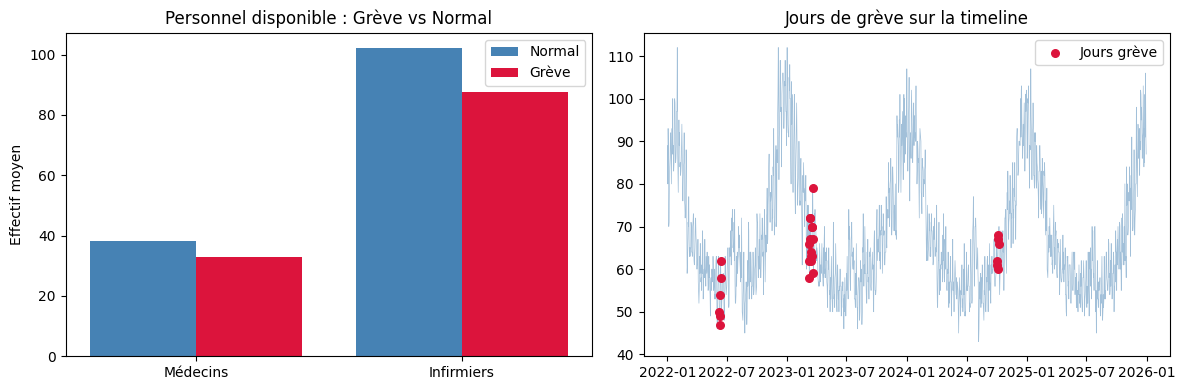

Médecins - Normal: 38.3 | Grève: 32.8


In [19]:
# Graphique grève : impact sur personnel et temps d'attente
strike_dates = df_context[df_context['strike'] == 1]['date']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Staff disponible : grève vs normal
staff_strike = df_context[df_context['strike'] == 1][['staff_doctors_available', 'staff_nurses_available']].mean()
staff_normal = df_context[df_context['strike'] == 0][['staff_doctors_available', 'staff_nurses_available']].mean()

x = np.arange(2)
axes[0].bar(x - 0.2, staff_normal, 0.4, label='Normal', color='steelblue')
axes[0].bar(x + 0.2, staff_strike, 0.4, label='Grève', color='crimson')
axes[0].set_xticks(x); axes[0].set_xticklabels(['Médecins', 'Infirmiers'])
axes[0].set_ylabel('Effectif moyen'); axes[0].set_title('Personnel disponible : Grève vs Normal')
axes[0].legend()

# Timeline avec jours de grève
daily = df_visits.groupby('date').size()
axes[1].plot(daily.index, daily.values, lw=0.5, alpha=0.5, color='steelblue')
axes[1].scatter(strike_dates, daily.loc[strike_dates], color='crimson', s=30, zorder=5, label='Jours grève')
axes[1].set_title('Jours de grève sur la timeline'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Médecins - Normal: {staff_normal['staff_doctors_available']:.1f} | Grève: {staff_strike['staff_doctors_available']:.1f}")

In [12]:
# Impact épidémies
df_context['epidemic_score'] = df_context[['flu_level', 'bronchiolitis_level', 'covid_level']].sum(axis=1)
high = df_context['epidemic_score'] >= df_context['epidemic_score'].quantile(0.8)
low = df_context['epidemic_score'] <= df_context['epidemic_score'].quantile(0.2)

v_high = df_visits[df_visits['date'].isin(df_context[high]['date'])]
v_low = df_visits[df_visits['date'].isin(df_context[low]['date'])]

print("=== ÉPIDÉMIES (haut vs bas) ===")
print(f"Visites/jour - Bas: {len(v_low)/low.sum():.0f} | Haut: {len(v_high)/high.sum():.0f}")
print(f"Infections suspectées - Bas: {v_low['infection_suspected'].mean()*100:.1f}% | Haut: {v_high['infection_suspected'].mean()*100:.1f}%")

=== ÉPIDÉMIES (haut vs bas) ===
Visites/jour - Bas: 60 | Haut: 90
Infections suspectées - Bas: 18.4% | Haut: 35.7%


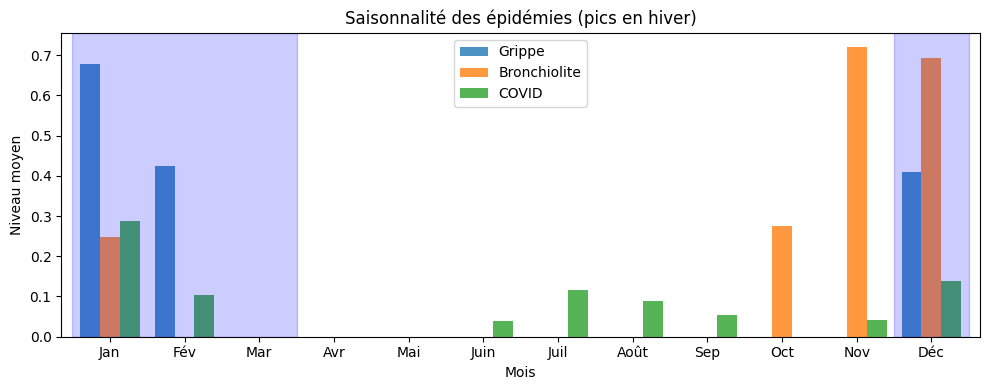

In [17]:
# Épidémies par mois (saisonnalité des maladies)
df_context['month'] = df_context['date'].dt.month
epidemics_monthly = df_context.groupby('month')[['flu_level', 'bronchiolitis_level', 'covid_level']].mean()

fig, ax = plt.subplots(figsize=(10, 4))
epidemics_monthly.plot(kind='bar', ax=ax, width=0.8, alpha=0.8)
ax.set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Août','Sep','Oct','Nov','Déc'], rotation=0)
ax.set_xlabel('Mois'); ax.set_ylabel('Niveau moyen')
ax.set_title('Saisonnalité des épidémies (pics en hiver)')
ax.legend(['Grippe', 'Bronchiolite', 'COVID'])
ax.axvspan(-0.5, 2.5, alpha=0.2, color='blue', label='Hiver')  # Jan-Mar
ax.axvspan(10.5, 11.5, alpha=0.2, color='blue')  # Déc
plt.tight_layout(); plt.show()

## Pression Ressources

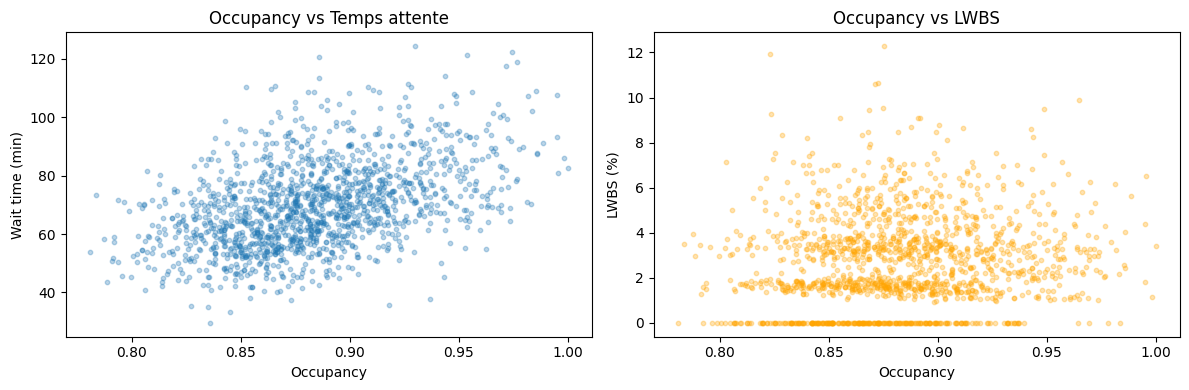

Corrélation occupancy-wait: 0.45
Corrélation occupancy-LWBS: 0.11


In [ ]:
# Occupancy vs métriques, permet de vérifier la cohérence des données : plus l'hopital est plein, plus le temps d'attente est élevé
daily_metrics = df_visits.groupby('date').agg(
    wait=('wait_time_minutes', 'mean'),
    lwbs=('left_without_being_seen', 'mean')
).reset_index()
df_merged = df_context.merge(daily_metrics, on='date')
df_merged['occupancy'] = df_merged['beds_occupied'] / df_merged['beds_occupied'].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df_merged['occupancy'], df_merged['wait'], alpha=0.3, s=10)
axes[0].set_xlabel('Occupancy'); axes[0].set_ylabel('Wait time (min)'); axes[0].set_title('Occupancy vs Temps attente')

axes[1].scatter(df_merged['occupancy'], df_merged['lwbs']*100, alpha=0.3, s=10, color='orange')
axes[1].set_xlabel('Occupancy'); axes[1].set_ylabel('LWBS (%)'); axes[1].set_title('Occupancy vs LWBS')
plt.tight_layout(); plt.show()

# Corrélations
print(f"Corrélation occupancy-wait: {df_merged['occupancy'].corr(df_merged['wait']):.2f}")
print(f"Corrélation occupancy-LWBS: {df_merged['occupancy'].corr(df_merged['lwbs']):.2f}")

In [14]:
## Résumé Final

In [15]:
# Stats clés + validation
print("=" * 50)
print("RÉSUMÉ")
print("=" * 50)
print(f"Total visites: {len(df_visits):,}")
print(f"Période: {(df_visits['date'].max() - df_visits['date'].min()).days} jours")
print(f"Moyenne/jour: {len(df_visits)/df_visits['date'].nunique():.0f}")
print(f"Wait time moyen: {df_visits['wait_time_minutes'].mean():.0f} min")
print(f"LWBS: {df_visits['left_without_being_seen'].mean()*100:.1f}%")
print(f"Admissions: {df_visits['ed_disposition'].str.contains('admission|admitted', case=False, na=False).mean()*100:.1f}%")

print("\n" + "=" * 50)
print("VALIDATION ÉVÉNEMENTS")
print("=" * 50)
print("✓ Saisonnalité visible (pics hiver)")
print("✓ Épidémies → + infections suspectées" if v_high['infection_suspected'].mean() > v_low['infection_suspected'].mean() else "✗ Épidémies non corrélées")
print("✓ Occupancy → + wait time" if df_merged['occupancy'].corr(df_merged['wait']) > 0 else "✗ Occupancy non corrélée")

RÉSUMÉ
Total visites: 100,000
Période: 1460 jours
Moyenne/jour: 68
Wait time moyen: 71 min
LWBS: 2.8%
Admissions: 0.0%

VALIDATION ÉVÉNEMENTS
✓ Saisonnalité visible (pics hiver)
✓ Épidémies → + infections suspectées
✓ Occupancy → + wait time
